# Single-band basics
Check display, likelihood calculation, especially gradient

In [ ]:
%reset -f
%run setup_notebook.py

from importlib import reload
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from like3 import pixel_table as _pt; reload(_pt)
PixelTable = _pt.PixelTable
from like3 import sourcelist as _sl; reload(_sl)
SourceModel = _sl.SourceModel
from like3 import main as _main; reload(_main)
BandLikelihood = _main.BandLikelihood
pt = PixelTable('files/kerr/toby_v4.fits')
sm = SourceModel.from_fermi_catalog('Geminga', version='v36')
band = pt[3,4]; 
bl = BandLikelihood(band, sm)

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Loaded Fermi 4FGL gll_psc_v36.fit: 7221 entries


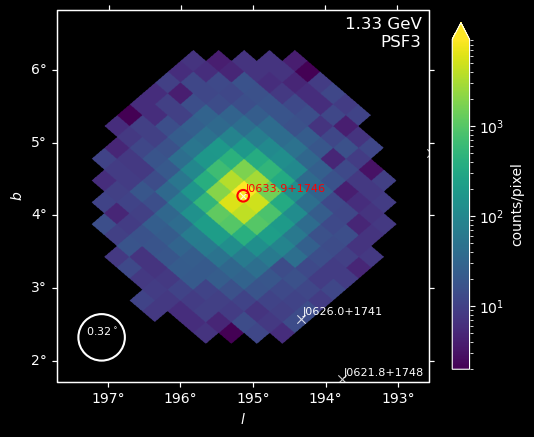

In [3]:
bl.zea_plot('photons');    

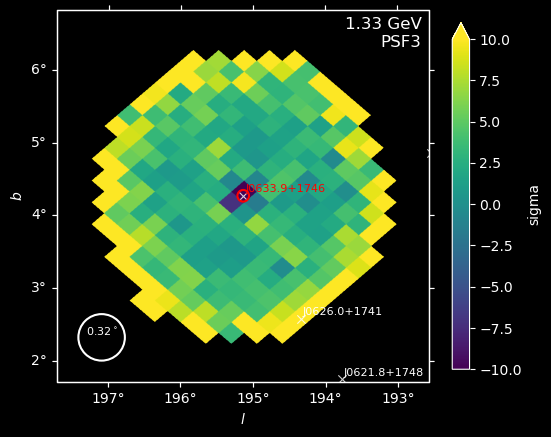

In [4]:
bl.zea_plot(bl.sigma, label='sigma', vmin=-10, vmax=10, log=False);   

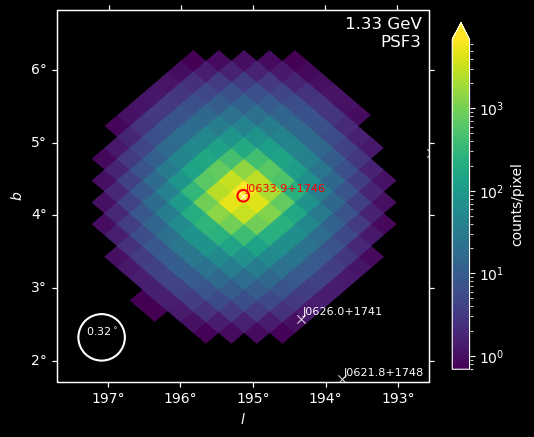

In [5]:
bl.zea_plot('source_counts');  

In [7]:
display(f""" ## Numerical gradient check for BandLikelihood""")
def numerical_gradient(loglike_fn, pars, eps=1e-3):
    """Compute numerical gradient of loglike_fn at pars using central differences."""
    grad = np.zeros_like(pars, dtype=float)
    for i in range(len(pars)):
        p_hi = np.array(pars, dtype=float)
        p_lo = np.array(pars, dtype=float)
        p_hi[i] += eps
        p_lo[i] -= eps
        f_hi = loglike_fn(p_hi)
        f_lo = loglike_fn(p_lo)
        grad[i] = (f_hi - f_lo) / (2 * eps)
    return grad

# Example usage: compare analytic and numerical gradients for BandLikelihood
pars0 = bl.parameters# if hasattr(bl.source_model, 'parameters') else np.concatenate([src.model.parameters[src.model.free] for src in bl.source_model])
ll, analytic_grad = bl.loglike_grad(pars0)
num_grad = numerical_gradient(lambda p: bl.loglike(p), pars0)
bl.parameters = pars0
print(f'Analytic gradient: {analytic_grad.round().astype(int)}')
print(f'Numerical gradient: {num_grad.round().astype(int)}')
print(f'Difference: {(analytic_grad - num_grad).round(1)}')

' ## Numerical gradient check for BandLikelihood'

Analytic gradient: [1758  204]
Numerical gradient: [1757  204]
Difference: [0.1 0. ]


In [17]:
self=pt
energy =1333; allowed_et=emin=emax=None
selected = []
for k, b in self.items():
    if allowed_et is not None and b.event_type not in allowed_et:
        continue
    if emin is not None and b.e0 < emin:
        continue
    if emax is not None and b.e0 >= emax:
        continue
    if energy is not None and not (b.e0 <= energy < b.e1):
        continue
    selected.append(k)
selected

[(0, 4), (1, 4), (2, 4), (3, 4)]

In [18]:
self.select(energy = 1333); self._selected

[(0, 4), (1, 4), (2, 4), (3, 4)]